In [2]:
import main as m
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 5000)
import seaborn as sns
import sqlite3
import matplotlib.pyplot as plt


In [3]:
db_path = 'human_genome.db'
sample_id = 'random_id'
res = pd.concat([
    pd.read_parquet('/s/project/cancer_pred/MASTER/final_res/cnv_germline_high_confidence.parquet'),
    pd.read_parquet('/s/project/cancer_pred/MASTER/final_res/cnv_AMP_HDEL.parquet')
], ignore_index=True)

res['geneID_short'] = res['Gene'].astype(str).str.split('.').str[0].str.strip()


outrider = pd.read_parquet('/s/project/cancer_pred/MASTER/final_res/outrider_or_variants_predisppadjust_cnv.parquet')
outrider['geneID_short'] = outrider['geneID_short'].astype(str).str.split('.').str[0].str.strip()

df = pd.merge(
    outrider, 
    res[[sample_id, 'geneID_short']], 
    on=[sample_id, 'geneID_short'], 
    how='left'
)

df['CNV'] = df['CNV'].fillna('No CNV')

In [4]:
res = m.cis_trans(df)

results = m.find_trans_drivers(res)
results = m.get_chromosomal_relationship(results, db_path)


--- CHROMOSOMAL ANALYSIS ---
Percentage of Driver-Target pairs on different chromosomes: 94.73%


In [5]:
summary = results.copy()
summary['Has_CNV_Driver'] = summary['driver_gene'].notna()

ex = summary.groupby(sample_id)['Has_CNV_Driver'].any().value_counts(normalize=True)

print(f"Percentage of samples where trans-effects co-occur with at least one CNV: {ex[True]*100:.2f}%")

unique_drivers = pd.DataFrame(results['driver_gene'].unique(), columns=['geneID_short'])

driver_pathway_summary = m.get_top_pathways(unique_drivers, db_path, n=15)

print("=== TOP PATHWAYS OF IDENTIFIED DRIVERS ===")
print(driver_pathway_summary.to_string(index=False))

trans_chrom_hits = results[results['is_trans_chromosomal'] == True]

print("=== TOP CROSS-CHROMOSOME INTERACTIONS ===")
print(trans_chrom_hits[[sample_id, 'driver_gene', 'driver_chrom', 'target_gene', 'target_chrom']].head(50))

Percentage of samples where trans-effects co-occur with at least one CNV: 74.15%
=== TOP PATHWAYS OF IDENTIFIED DRIVERS ===
                                                             pathway_name  unique_outlier_genes
                                                 Neutrophil degranulation                   315
                                            Generic Transcription Pathway                   273
              Antigen processing: Ubiquitination & Proteasome degradation                   232
                                            mRNA Splicing - Major Pathway                   192
                                                              Neddylation                   184
            Major pathway of rRNA processing in the nucleolus and cytosol                   166
                                           Dengue Virus-Host Interactions                   166
                                          Separation of Sister Chromatids                   151
            

/scratch/tmp/deben/ipykernel_1338556/746069446.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


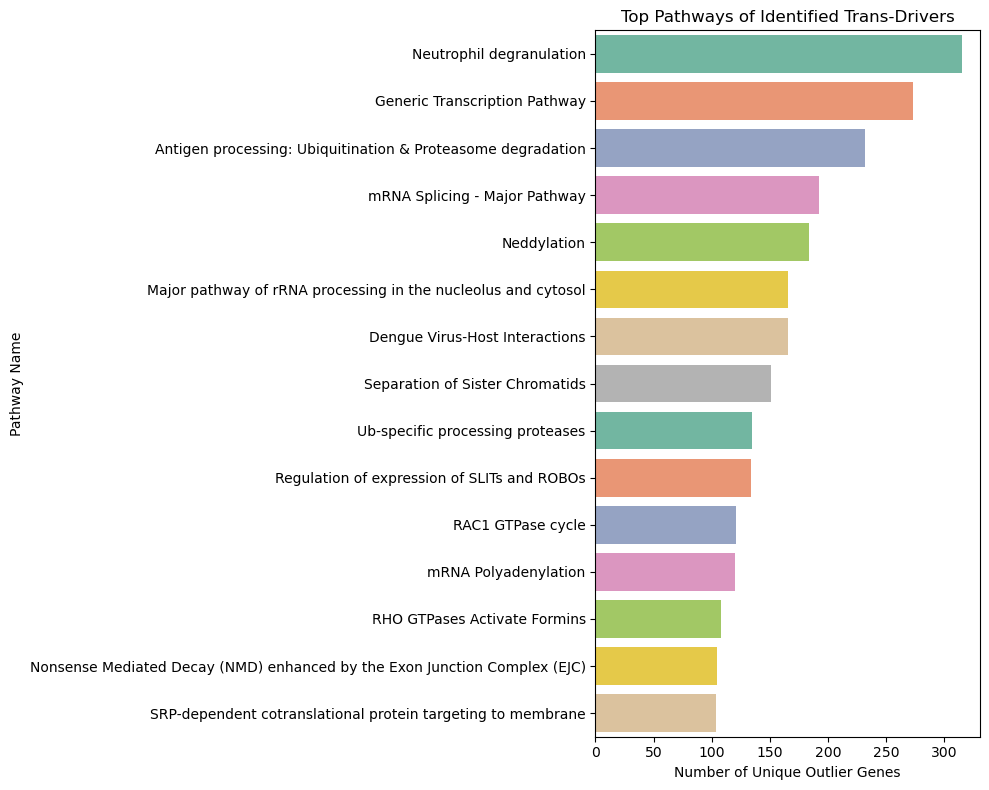

In [6]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=driver_pathway_summary.head(15), 
    x='unique_outlier_genes', 
    y='pathway_name', 
    palette='Set2'
)
plt.title('Top Pathways of Identified Trans-Drivers')
plt.xlabel('Number of Unique Outlier Genes')
plt.ylabel('Pathway Name')
plt.tight_layout()
plt.show()

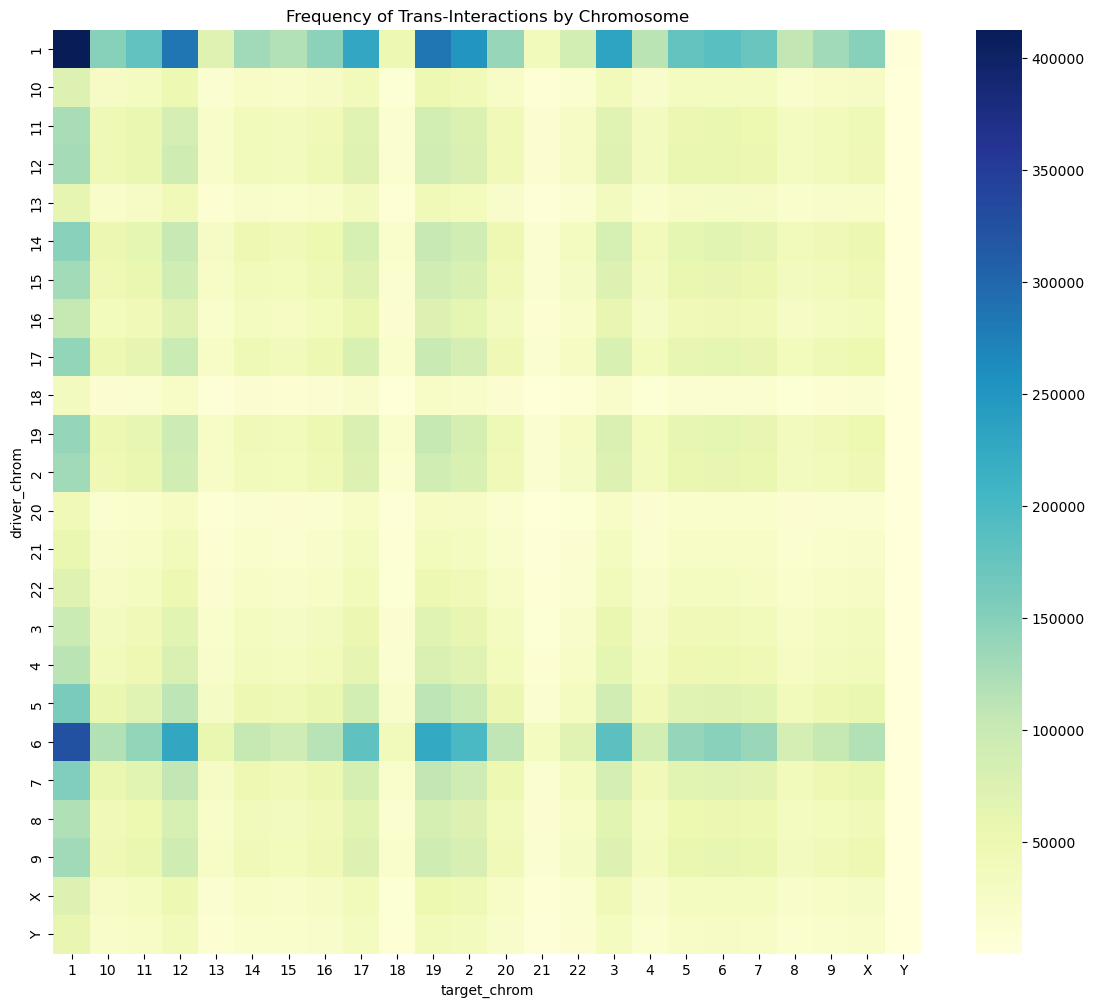

In [19]:
interaction_matrix = pd.crosstab(results['driver_chrom'], results['target_chrom'])

plt.figure(figsize=(14, 12))
sns.heatmap(
    interaction_matrix, 
    annot=False, 
    fmt='.2g', 
    cmap='YlGnBu',
    annot_kws={"size": 6} )
plt.title('Frequency of Trans-Interactions by Chromosome')
plt.show()

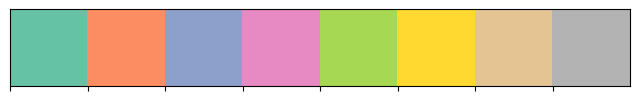

In [20]:
sns.palplot(sns.color_palette("Set2"))

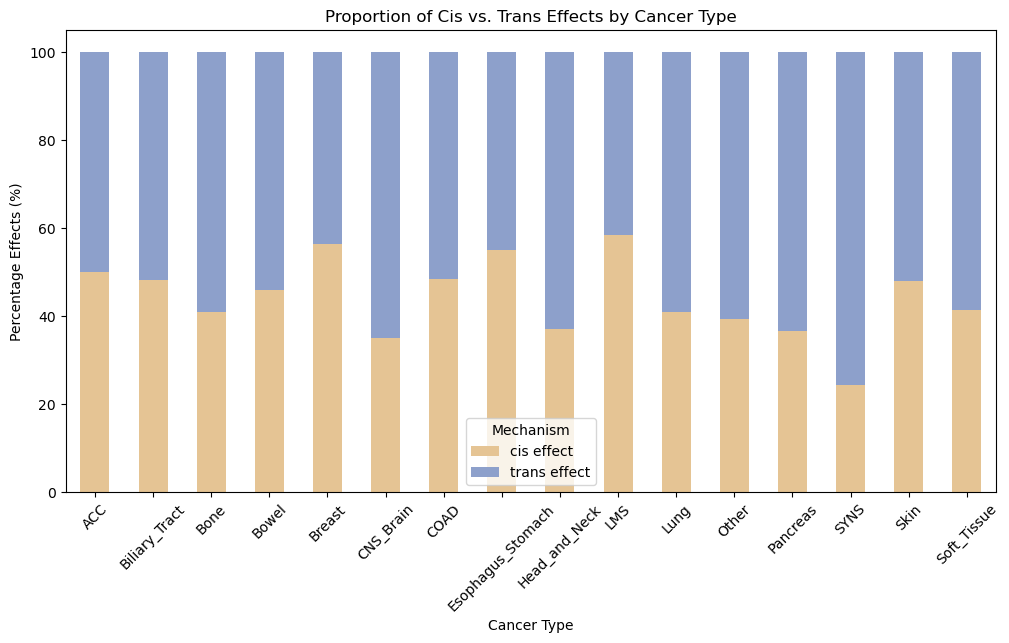

In [23]:
diag_mechanism = res.groupby(['Diag', 'Mechanism']).size().unstack().fillna(0)
diag_mechanism_pct = diag_mechanism.div(diag_mechanism.sum(axis=1), axis=0) * 100

diag_mechanism_pct.plot(kind='bar', stacked=True, figsize=(12, 6), color=[sns.color_palette("Set2")[6], sns.color_palette("Set2")[2]])
plt.title('Proportion of Cis vs. Trans Effects by Cancer Type')
plt.ylabel('Percentage Effects (%)')
plt.xlabel('Cancer Type')
plt.legend(title='Mechanism')
plt.xticks(rotation=45)
plt.show()

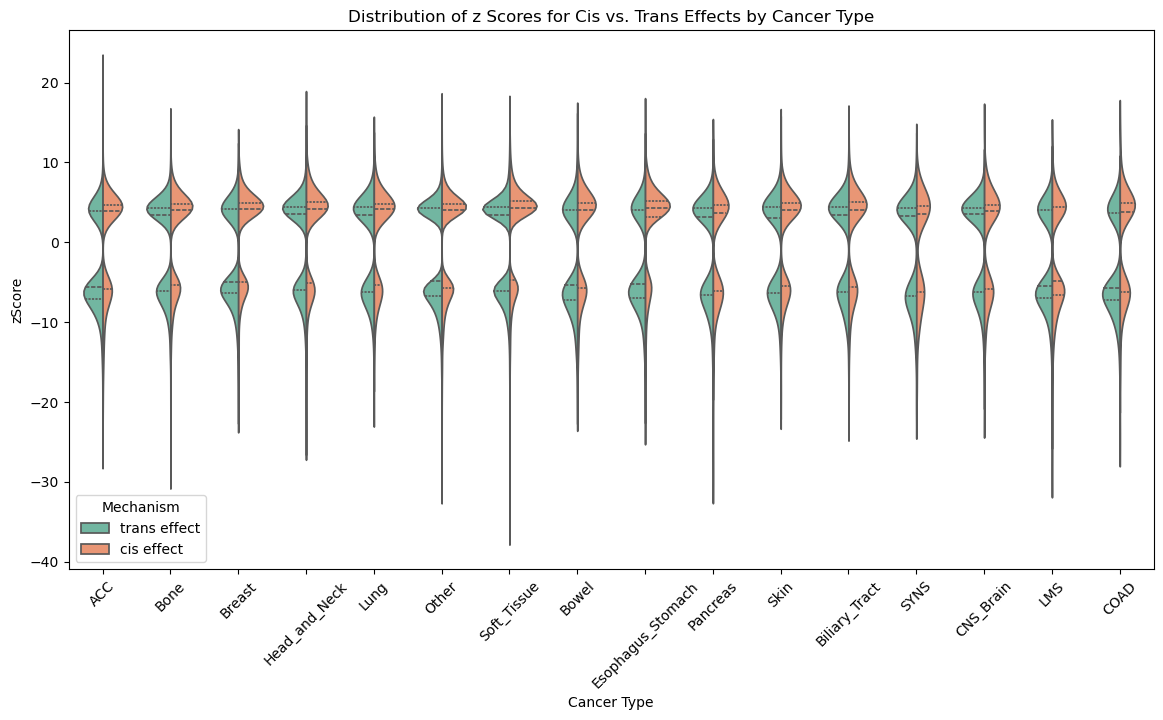

In [26]:
plt.figure(figsize=(14, 7))
sns.violinplot(
    data=res, 
    x='Diag', 
    y='zScore', 
    palette='Set2',
    hue='Mechanism', 
    split=True, 
    inner='quart',
)
plt.title('Distribution of z Scores for Cis vs. Trans Effects by Cancer Type')
plt.xticks(rotation=45)
plt.xlabel('Cancer Type')
plt.show()